# 3.3.1 Spatio-Temporal Simulation in 2 Dimensions (Mucus Layer)

2D Mucus Layer Simulation 
Simulating ~150 µm human colon mucus layer with COMETS

**Grid:** 30 x 15 (300 um wide x 150 um deep)

**Species:** *Bifidobacterium longum infantis*, *Anaerobutyricum hallii*

**Scenario:** Glucose supplied at top (lumen), diffuses downward; cross-feeding via lactate/acetate/butyrate

In [1]:
import os
# # Change the paths to your installation locations
# # Env Variables may by unnecessary if set in .bashrc, .zshrc, Dockerfile, etc. Uncomment and change as needed.
# os.environ['GUROBI_COMETS_HOME'] = '/Library/gurobi1003/macos_universal2'
# os.environ['COMETS_HOME'] = '/Users/fredericksenya/Documents/MATLAB/comets_macos/comets_2.12.3'
# os.environ['CLASSPATH'] = f"{os.environ['COMETS_HOME']}/comets.jar:{os.environ['GUROBI_COMETS_HOME']}/lib/gurobi.jar"
# os.environ['DYLD_LIBRARY_PATH'] = f"{os.environ['GUROBI_COMETS_HOME']}/lib"
# os.environ['GRB_LICENSE_FILE'] = '/Library/gurobi1003/macos_universal2/gurobi.lic'

os.environ['GUROBI_COMETS_HOME'] = '/Library/gurobi1003/macos_universal2'
os.environ['COMETS_HOME'] = '/Users/david/comets_macos/comets_2.12.5'
os.environ['CLASSPATH'] = f"{os.environ['COMETS_HOME']}/comets.jar:{os.environ['GUROBI_COMETS_HOME']}/lib/gurobi.jar"
os.environ['DYLD_LIBRARY_PATH'] = f"{os.environ['GUROBI_COMETS_HOME']}/lib"
os.environ['GRB_LICENSE_FILE'] = '/Users/david/gurobi.lic'

import cobra as cb
import cometspy as c
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
##Load COBRA Models

model_BI = cb.io.load_matlab_model('Bifidobacterium_longum_infantis_ATCC_15697.mat')
model_BI.id = 'b_infantis'

model_AH = cb.io.load_matlab_model('Eubacterium_hallii_DSM_3353.mat')
model_AH.id = 'a_hallii'

print(f"B. infantis: {len(model_BI.reactions)} rxns, {len(model_BI.metabolites)} mets, {len(model_BI.exchanges)} exchanges")
print(f"A. hallii: {len(model_AH.reactions)} rxns, {len(model_AH.metabolites)} mets, {len(model_AH.exchanges)} exchanges")

Set parameter Username
Academic license - for non-commercial use only - expires 2027-02-19


No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e
No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e


B. infantis: 1032 rxns, 932 mets, 163 exchanges
A. hallii: 1051 rxns, 980 mets, 120 exchanges


In [3]:
#FBA for Both Models 

for label, model in [('b_infantis', model_BI), ('a_hallii', model_AH)]:
    with model:
        for rxn in model.exchanges:
            rxn.lower_bound = -1000
            rxn.upper_bound = 1000
        sol = model.optimize()
        print(f"{label} max growth (unlimited media): {sol.objective_value:.4f} 1/h")

b_infantis max growth (unlimited media): 60.8202 1/h
a_hallii max growth (unlimited media): 67.1662 1/h


## Set up COMETS Simulation

Valid Parameters and Options (See pdf below, page 26)

[Supplement Discussions (PDF)](https://pmc.ncbi.nlm.nih.gov/articles/instance/10824140/bin/NIHMS1948756-supplement-Supplement_Discussions.pdf)

---

GEMs Files available [AGORA2 at vmh.life](https://www.vmh.life/files/reconstructions/AGORA2/version2.01/mat_files/individual_reconstructions/) or directly:

[*Anaerobutyricum hallii* - *A. hallii* (Previously Eubacterium hallii)](https://www.vmh.life/files/reconstructions/AGORA2/version2.01/mat_files/individual_reconstructions/Eubacterium_hallii_DSM_3353.mat) 

[*Bifidobacterium longum sbsp. infantis* - *B. infantis*](https://www.vmh.life/files/reconstructions/AGORA2/version2.01/mat_files/individual_reconstructions/Bifidobacterium_longum_infantis_ATCC_15697.mat) 

In [4]:
# Build Exchange Metabolite Union & Add Missing Exchanges

# Map metabolite_id -> exchange_reaction_id for each model
met_to_ex_BI, met_to_ex_AH = {}, {}
for rxn in model_BI.exchanges:
    if rxn.metabolites:
        met_to_ex_BI[list(rxn.metabolites.keys())[0].id] = rxn.id
for rxn in model_AH.exchanges:
    if rxn.metabolites:
        met_to_ex_AH[list(rxn.metabolites.keys())[0].id] = rxn.id


all_ext_mets = set(met_to_ex_BI.keys()) | set(met_to_ex_AH.keys())
print(f"Total unique external metabolites: {len(all_ext_mets)}")


# COMETS fix for index out of range error
def add_missing_closed_exchanges(model, met_to_ex_self, all_ext_mets, label):
    met_ids = {m.id for m in model.metabolites}
    rxn_ids = {r.id for r in model.reactions}
    added = 0
    for met_id in all_ext_mets:
        if met_id in met_to_ex_self:
            continue
        if met_id in met_ids:
            met = model.metabolites.get_by_id(met_id)
        else:
            met = cb.Metabolite(met_id, compartment='e')
            model.add_metabolites([met])
            met_ids.add(met_id)
        rxn_id = f'EX_added_{met_id}'
        if rxn_id in rxn_ids:
            continue
        rxn = cb.Reaction(rxn_id)
        rxn.name = f'Dummy exchange for {met_id} (closed)'
        rxn.lower_bound = 0.0
        rxn.upper_bound = 0.0
        rxn.add_metabolites({met: -1.0})
        model.add_reactions([rxn])
        rxn_ids.add(rxn_id)
        added += 1
    print(f'[{label}] Added {added} closed dummy exchanges')

add_missing_closed_exchanges(model_BI, met_to_ex_BI, all_ext_mets, 'b_infantis')
add_missing_closed_exchanges(model_AH, met_to_ex_AH, all_ext_mets, 'a_hallii')

Total unique external metabolites: 188
[b_infantis] Added 25 closed dummy exchanges
[a_hallii] Added 68 closed dummy exchanges


In [5]:
# COMETS Models

for m in [model_BI, model_AH]:
    for rxn in m.exchanges:
        rxn.lower_bound = 0.0
        rxn.upper_bound = 1000.0

comets_BI = c.model(model_BI)
comets_AH = c.model(model_AH)

comets_BI.open_exchanges()
comets_AH.open_exchanges()

# Clean non-EX exchanges (COMETS fix)
for m in [comets_BI, comets_AH]:
    ex_mask = m.reactions['EXCH'].isin([True, 'True'])
    exchanges_df = m.reactions[ex_mask]
    for name in exchanges_df['REACTION_NAMES']:
        name = str(name)
        if not name.startswith('EX_'):
            m.reactions.loc[m.reactions['REACTION_NAMES'] == name, 'EXCH'] = False
            m.reactions.loc[m.reactions['REACTION_NAMES'] == name, 'EXCH_IND'] = 0

print(f'BI COMETS: {len(comets_BI.reactions)} reactions')
print(f'AH COMETS: {len(comets_AH.reactions)} reactions')

Bifido COMETS: 1057 reactions
Eubacterium COMETS: 1119 reactions


In [6]:
# GRID GEOMETRY

GRID_X = 30                  # cells wide
GRID_Y = 15                  # cells deep
MUCUS_THICKNESS_UM = 150     # total mucus depth (microns)

SPACE_WIDTH = MUCUS_THICKNESS_UM / GRID_Y / 1e4   # cm per cell
# = 150/15/10000 = 0.001 cm = 10 um per cell

BOX_VOL_CM3 = SPACE_WIDTH ** 3       # cm3 per box = 1e-9 cm3
BOX_VOL_ML  = BOX_VOL_CM3            # 1 cm3 = 1 mL
BOX_VOL_L   = BOX_VOL_ML * 1e-3      # 1e-12 L


# concentration (mM) -> amount (mmol) per box 
def mM_to_mmol(conc_mM):
    """Convert mM (= mmol/L) to mmol amount per COMETS box"""
    return conc_mM * BOX_VOL_L   # mmol/L * L = mmol

def mmol_to_mM(amount_mmol):
    """Convert mmol amount per box back to mM concentration."""
    return amount_mmol / BOX_VOL_L


# Aqueous diffusion at 25C (literature values)
D_glucose_aq   = 6.7e-6   # cm2/s — glucose 
D_lactate_aq   = 1.1e-5   # cm2/s — lactate
D_acetate_aq   = 1.2e-5   # cm2/s — acetate
D_butyrate_aq  = 0.9e-5   # cm2/s — butyrate
D_generic_aq   = 8.0e-6   # cm2/s — small molecule


MUCUS_FACTOR_GLUCOSE = 0.003     # 0.3% of aqueous diffusion
MUCUS_FACTOR_SECRETED = 0.003   # 0.3% of aqueous diffusion
MUCUS_FACTOR_DEFAULT = 0.003    # 0.3% of aqueous diffusion


# In dense mucus
D_GLUCOSE  = D_glucose_aq  * MUCUS_FACTOR_GLUCOSE    
D_LACTATE  = D_lactate_aq  * MUCUS_FACTOR_SECRETED 
D_ACETATE  = D_acetate_aq  * MUCUS_FACTOR_SECRETED 
D_BUTYRATE = D_butyrate_aq * MUCUS_FACTOR_SECRETED 
D_DEFAULT  = D_generic_aq  * MUCUS_FACTOR_DEFAULT 


# Diffusion Timescale
L = GRID_Y * SPACE_WIDTH  # total depth in cm

TIME_STEP = 0.01          # hours per cycle
NUM_DIFF_PER_STEP = 10    # diffusion substeps per cycle
KM_VALUE = 5e-4           # mmol/cm³ = 0.5 mM 


print(f"Diffusion timescale (tau = L^2 / 2D)") 
print(f" \n Mucus depth: {L*1e4:.0f} um = {L} cm")
for name, D in [('Glucose', D_GLUCOSE), ('Lactate', D_LACTATE),
                ('Acetate', D_ACETATE), ('Butyrate', D_BUTYRATE)]:
    tau_s = L**2 / (2 * D)
    tau_min = tau_s / 60
    print(f"  {name:12s}: tau = {tau_s:.0f} s = {tau_min:.1f} min")

Diffusion timescale (tau = L^2 / 2D)
 
 Mucus depth: 150 um = 0.015 cm
  Glucose     : tau = 5597 s = 93.3 min
  Lactate     : tau = 3409 s = 56.8 min
  Acetate     : tau = 3125 s = 52.1 min
  Butyrate    : tau = 4167 s = 69.4 min


In [7]:
# Metabolite Concentrations

GLC_CONC_mM = 10.0         
GLC_TOP = mM_to_mmol(GLC_CONC_mM) 

WATER_AMOUNT = 1e-4         # mmol/box (≈ 10^8 mM, unlimited)

MAJOR_ION_CONC = 5.0
MAJOR_ION = mM_to_mmol(MAJOR_ION_CONC)

AA_CONC = 2.0   #amino acid concentration
AA_AMOUNT = mM_to_mmol(AA_CONC)

TRACE_CONC = 0.1  #Trace metals
TRACE_AMOUNT = mM_to_mmol(TRACE_CONC)

VIT_CONC = 0.1
VIT_AMOUNT = mM_to_mmol(VIT_CONC)

NUTRIENT_CONC = 5.0
NUTRIENT_AMOUNT = mM_to_mmol(NUTRIENT_CONC)

print(f"METABOLITE AMOUNTS PER BOX")
print(f"\n  Glucose (top):  {GLC_TOP:.2e} mmol  ({GLC_CONC_mM} mM)")
print(f"  Water/H+:       {WATER_AMOUNT:.2e} mmol  (unlimited)")
print(f"  Major ions:     {MAJOR_ION:.2e} mmol  ({MAJOR_ION_CONC} mM)")
print(f"  Amino acids:    {AA_AMOUNT:.2e} mmol  ({AA_CONC} mM)")
print(f"  Trace metals:   {TRACE_AMOUNT:.2e} mmol  ({TRACE_CONC} mM)")
print(f"  Vitamins:       {VIT_AMOUNT:.2e} mmol  ({VIT_CONC} mM)")
print(f"  Nutrients:       {NUTRIENT_AMOUNT:.2e} mmol  ({NUTRIENT_CONC} mM)")

METABOLITE AMOUNTS PER BOX

  Glucose (top):  1.00e-11 mmol  (10.0 mM)
  Water/H+:       1.00e-04 mmol  (unlimited)
  Major ions:     5.00e-12 mmol  (5.0 mM)
  Amino acids:    2.00e-12 mmol  (2.0 mM)
  Trace metals:   1.00e-13 mmol  (0.1 mM)
  Vitamins:       1.00e-13 mmol  (0.1 mM)
  Nutrients:       5.00e-12 mmol  (5.0 mM)


In [8]:
# media metabolites

water_proton_ids = {'h2o[e]'}
major_ion_ids = {'k[e]', 'cl[e]', 'mg2[e]', 'ca2[e]',}
trace_metal_ids = {'fe2[e]', 'fe3[e]', 'zn2[e]', 'cu2[e]', 'mn2[e]', 'cobalt2[e]', 'cd2[e]',}
vitamin_ids = {'ribflv[e]', 'pnto_R[e]', 'nac[e]','hxan[e]',}
aa_ids = {'ala_L[e]', 'asn_L[e]','his_L[e]','leu_L[e]', 'lys_L[e]', 'met_L[e]', 'glycys[e]','glyglu[e]',}
nutrient_ids = {'nh4[e]', 'pi[e]', 'so4[e]',}
glucose_id = 'glc_D[e]'


# # Classify each metabolite
met_categories = {}
for met_id in all_ext_mets:
    if met_id == glucose_id:
        met_categories[met_id] = ('glucose', GLC_TOP)
    elif met_id in water_proton_ids:
        met_categories[met_id] = ('water_proton', WATER_AMOUNT)
    elif met_id in major_ion_ids:
        met_categories[met_id] = ('major_ion', MAJOR_ION)
    elif met_id in trace_metal_ids:
        met_categories[met_id] = ('trace_metal', TRACE_AMOUNT)
    elif met_id in vitamin_ids:
        met_categories[met_id] = ('vitamin', VIT_AMOUNT)
    elif met_id in aa_ids:
        met_categories[met_id] = ('amino_acid', AA_AMOUNT)
    elif met_id in nutrient_ids:
        met_categories[met_id] = ('nutrient', NUTRIENT_AMOUNT) 

In [9]:
INIT_BIOMASS = 5e-10   # grams ~ 500 bacteria 

x_init_BI = 7              # left side
x_init_AH = 22            # right side 
y_init = 2             # 20 um into mucus

comets_BI.initial_pop = [[x_init_BI, y_init, INIT_BIOMASS]]
comets_AH.initial_pop = [[x_init_AH, y_init, INIT_BIOMASS]]

# layout
layout = c.layout([comets_BI, comets_AH])
layout.grid = [GRID_X, GRID_Y]

# Zero all metabolites
for met in all_ext_mets:
    layout.set_specific_metabolite(met, 0.0)
    layout.set_specific_refresh(met, 0.0)

# set nutrients static
for met_id, (category, amount) in met_categories.items():
    if category == 'glucose':
        continue
    if amount > 0:
        layout.set_specific_metabolite(met_id, amount)
        layout.set_specific_static(met_id, amount)


#  Glucose: top row static, bottom row zero 
for x in range(GRID_X):
    layout.set_specific_metabolite_at_location(glucose_id, (x, 0), GLC_TOP)
    layout.set_specific_static_at_location(glucose_id, (x, 0), GLC_TOP)

for x in range(GRID_X):
    layout.set_specific_metabolite_at_location(glucose_id, (x, GRID_Y - 1), 0.0)
    layout.set_specific_static_at_location(glucose_id, (x, GRID_Y - 1), 0.0)


#  Metabolite specific diffusion (cm2/s)
layout.set_specific_metabolite_diffusion(glucose_id, D_GLUCOSE)
secreted_diffusion = { 'lac_L[e]': D_LACTATE, 'ac[e]': D_ACETATE, 'but[e]':   D_BUTYRATE,}

for met, d_val in secreted_diffusion.items():
    if met in all_ext_mets:
        layout.set_specific_metabolite_diffusion(met, d_val)


In [10]:
# Biomass Motion Parameters

# bacteria are non-motile in mucus. very slow biomass spreading
D0_biomass = 1e-10     # cm²/s — baseline (non-motile, viscous mucus)
Dn_biomass = 1e-8      # cm²/s — enhanced at high density (mechanical pushing)
n_exp      = 1.0       # linear density dependence
N_hill     = 2.0       # Hill coefficient for growth-dependent diffusion
K_half     = 1e-12     # g — half-saturation for Hill function

for m in [comets_BI, comets_AH]:
    m.add_nonlinear_diffusion_parameters(D0_biomass, Dn_biomass, n_exp, N_hill, K_half)

In [11]:
#Parameters

params = c.params()
params.set_param('maxCycles', 600)         
params.set_param('timeStep', 0.01)             # 0.01 h = 36 s per cycle

params.set_param('spaceWidth', SPACE_WIDTH)    # 0.001 cm = 10 um
params.set_param('exchangestyle', 'Monod Style')
params.set_param('defaultVmax', 20.0)          # mmol/g/h
params.set_param('defaultKm', 5e-4)            # mmol/cm3 = 0.5 mM
params.set_param('defaultHill', 1)             # standard Monod
params.set_param('defaultDiffConst', D_DEFAULT)  # cm2/s
params.set_param('numDiffPerStep', 10)

params.set_param('biomassMotionStyle', 'ConvNonlin Diffusion 2D')
params.set_param('growthDiffRate', 0.0)

params.set_param('maxSpaceBiomass', 1e-9)    # g
params.set_param('minSpaceBiomass', 1e-14)   # g
params.set_param('allowCellOverlap', True)
params.set_param('deathRate', 0.0)

LOG_RATE = 5  
params.set_param('writeBiomassLog', True)
params.set_param('BiomassLogRate', LOG_RATE)
params.set_param('writeMediaLog', True)
params.set_param('MediaLogRate', LOG_RATE)
params.set_param('writeFluxLog', True)
params.set_param('FluxLogRate', LOG_RATE)
params.set_param('writeTotalBiomassLog', True)
params.set_param('totalBiomassLogRate', LOG_RATE)

In [12]:
# Simulation

sim = c.comets(layout, params)
sim.run()
print("\nSimulation complete.")


Running COMETS simulation ...

Debug Here ...
Done!

Simulation complete.


In [13]:
# Output
output_lines = str(sim.run_output).strip().split('\n')
print("Last 25 lines of COMETS output")
for line in output_lines[-25:]:
    print(line)

Last 25 lines of COMETS output
Model a_hallii.cmd: 2.142372720912208E-9
Cycle 598
Here OK!
total_fba_time  324
total_diff_time  14
Total biomass:
Model b_infantis.cmd: 8.307807024401828E-10
Model a_hallii.cmd: 2.1466836491418032E-9
Cycle 599
Here OK!
total_fba_time  325
total_diff_time  14
Total biomass:
Model b_infantis.cmd: 8.316413748652794E-10
Model a_hallii.cmd: 2.1509968532695186E-9
Cycle 600
Here OK!
total_fba_time  323
total_diff_time  14
Total biomass:
Model b_infantis.cmd: 8.325023351793672E-10
Model a_hallii.cmd: 2.1553121140550633E-9
Cycle 601
End of simulation
Total time = 132.727s


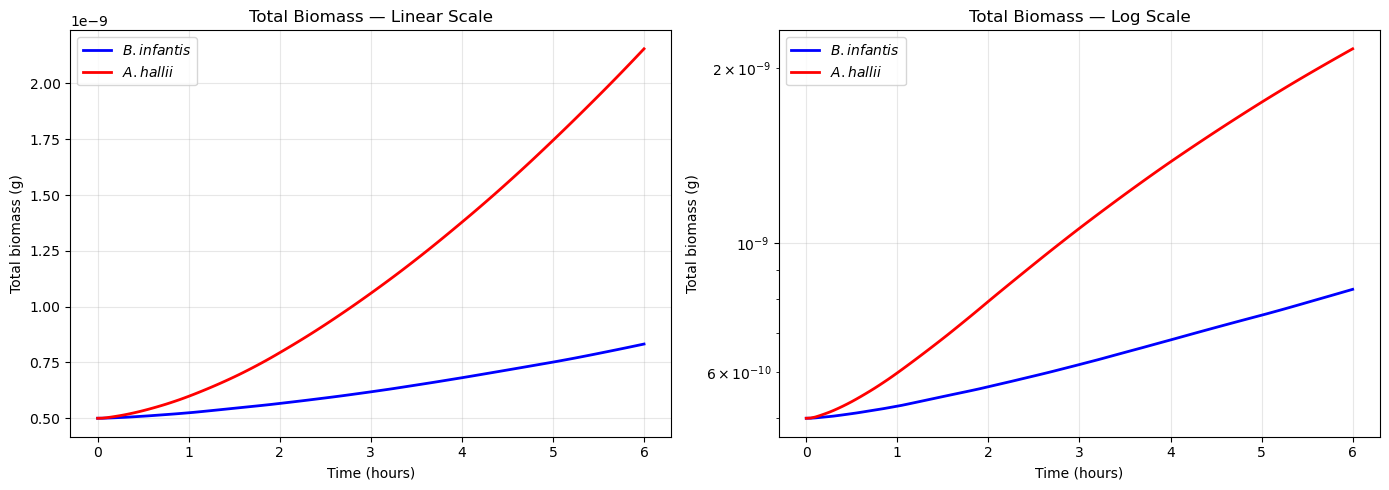

$\it{B. infantis}$:      5.00e-10 → 8.33e-10  (x1.7)
$\it{A. hallii}$: 5.00e-10 → 2.16e-09  (x4.3)


In [14]:
# Total Biomass Over Time
bio = sim.total_biomass
time_h = bio['cycle'] * 0.01 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
ax = axes[0]
ax.plot(time_h, bio['b_infantis'], 'b-', label=r'$\it{B. infantis}$', linewidth=2)
ax.plot(time_h, bio['a_hallii'], 'r-', label=r'$\it{A. hallii}$', linewidth=2)
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Total biomass (g)')
ax.set_title('Total Biomass — Linear Scale')
ax.legend()
ax.grid(True, alpha=0.3)

# Log scale
ax = axes[1]
ax.semilogy(time_h, bio['b_infantis'].clip(lower=1e-20), 'b-', label=r'$\it{B. infantis}$', linewidth=2)
ax.semilogy(time_h, bio['a_hallii'].clip(lower=1e-20), 'r-', label=r'$\it{A. hallii}$', linewidth=2)
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Total biomass (g)')
ax.set_title('Total Biomass — Log Scale')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('total_biomass.png', dpi=150, bbox_inches='tight')
plt.show()

# Growth summary
init_bio_BI = bio['b_infantis'].iloc[0]
final_bio_BI = bio['b_infantis'].iloc[-1]
init_bio_AH = bio['a_hallii'].iloc[0]
final_bio_AH = bio['a_hallii'].iloc[-1]
print(r"$\it{B. infantis}$:      "+ f"{init_bio_BI:.2e} → {final_bio_BI:.2e}  (x{final_bio_BI/max(init_bio_BI,1e-30):.1f})")
print(r"$\it{A. hallii}$: "+ f"{init_bio_AH:.2e} → {final_bio_AH:.2e}  (x{final_bio_AH/max(init_bio_AH,1e-30):.1f})")

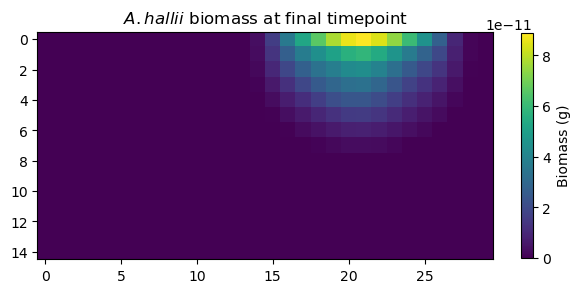

In [16]:
im = sim.get_biomass_image("a_hallii", 600)
im = np.roll(im, shift=1, axis=1) # shift , fixing a comets bug
plt.imshow(im.T, origin="upper") 
plt.title(r'$\it{A. hallii}$ biomass at final timepoint')
plt.colorbar(shrink=0.5, label='Biomass (g)')
plt.tight_layout()
plt.show()

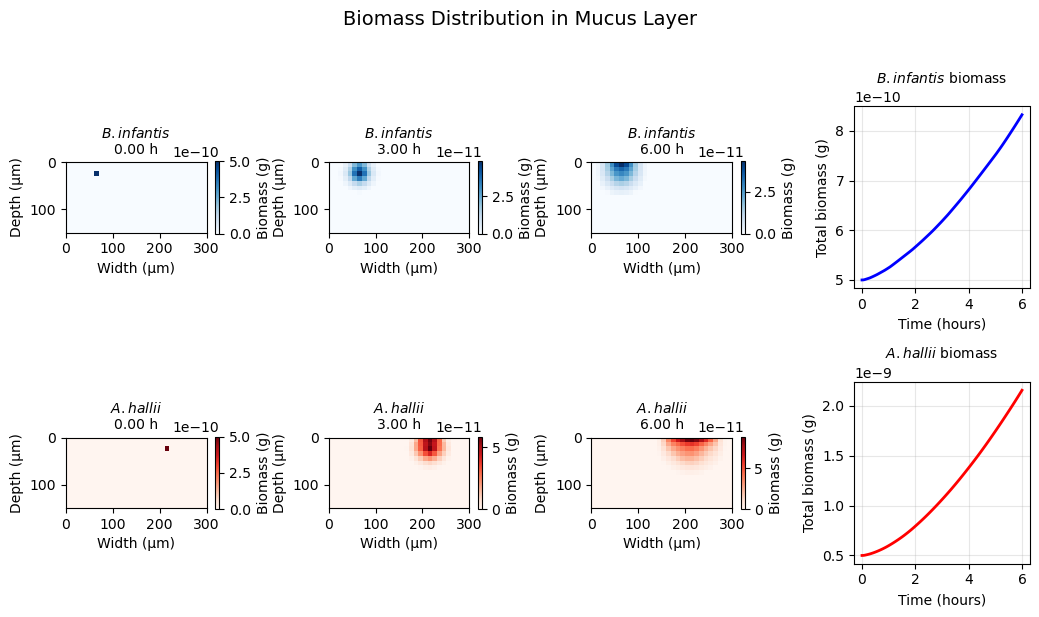

In [50]:
# Biomass Heatmaps Over Time
cycles = [0, 300, 600]  

fig, axes = plt.subplots(2, len(cycles) + 1, figsize=(3.5*len(cycles), 6))
if len(cycles) == 1:
    axes = axes.reshape(2, 1)

for i, cyc in enumerate(cycles):
    for j, (species, id, cmap) in enumerate([(r'$\it{B. infantis}$', 'b_infantis', 'Blues'), (r'$\it{A. hallii}$', 'a_hallii', 'Reds')]):
        ax = axes[j, i]
        im = sim.get_biomass_image(id, cyc)
        im = np.roll(im, shift=1, axis=1) # shift , fixing a comets bug

        pcm = ax.imshow(im.T, origin='upper', cmap=cmap, aspect='equal',
                        extent=[0, GRID_X*SPACE_WIDTH*1e4, GRID_Y*SPACE_WIDTH*1e4, 0])
        ax.set_title(f'{species}\n{cyc*0.01:.2f} h', fontsize=10)
        ax.set_xlabel('Width (µm)')
        ax.set_ylabel('Depth (µm)')
        plt.colorbar(pcm, ax=ax, shrink=0.4, label='Biomass (g)')

ax = axes[0, -1]
ax.plot(time_h, bio['b_infantis'], 'b-', label=r'$\it{B. infantis}$', linewidth=2)
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Total biomass (g)')
ax.set_title(r'$\it{B. infantis}$ biomass', fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1, -1]
ax.plot(time_h, bio['a_hallii'], 'r-', label=r'$\it{A. hallii}$', linewidth=2)
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Total biomass (g)')
ax.set_title(r'$\it{A. hallii}$ biomass', fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('Biomass Distribution in Mucus Layer', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

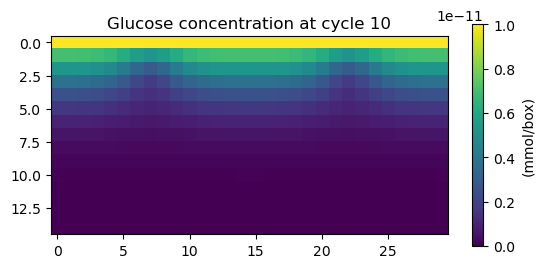

In [17]:
met="glc_D[e]"
im = sim.get_metabolite_image(met, 10)

plt.imshow(im.T, origin="upper")
plt.colorbar(shrink=0.6, label='(mmol/box)')
plt.title('Glucose concentration at cycle 10')
plt.show()

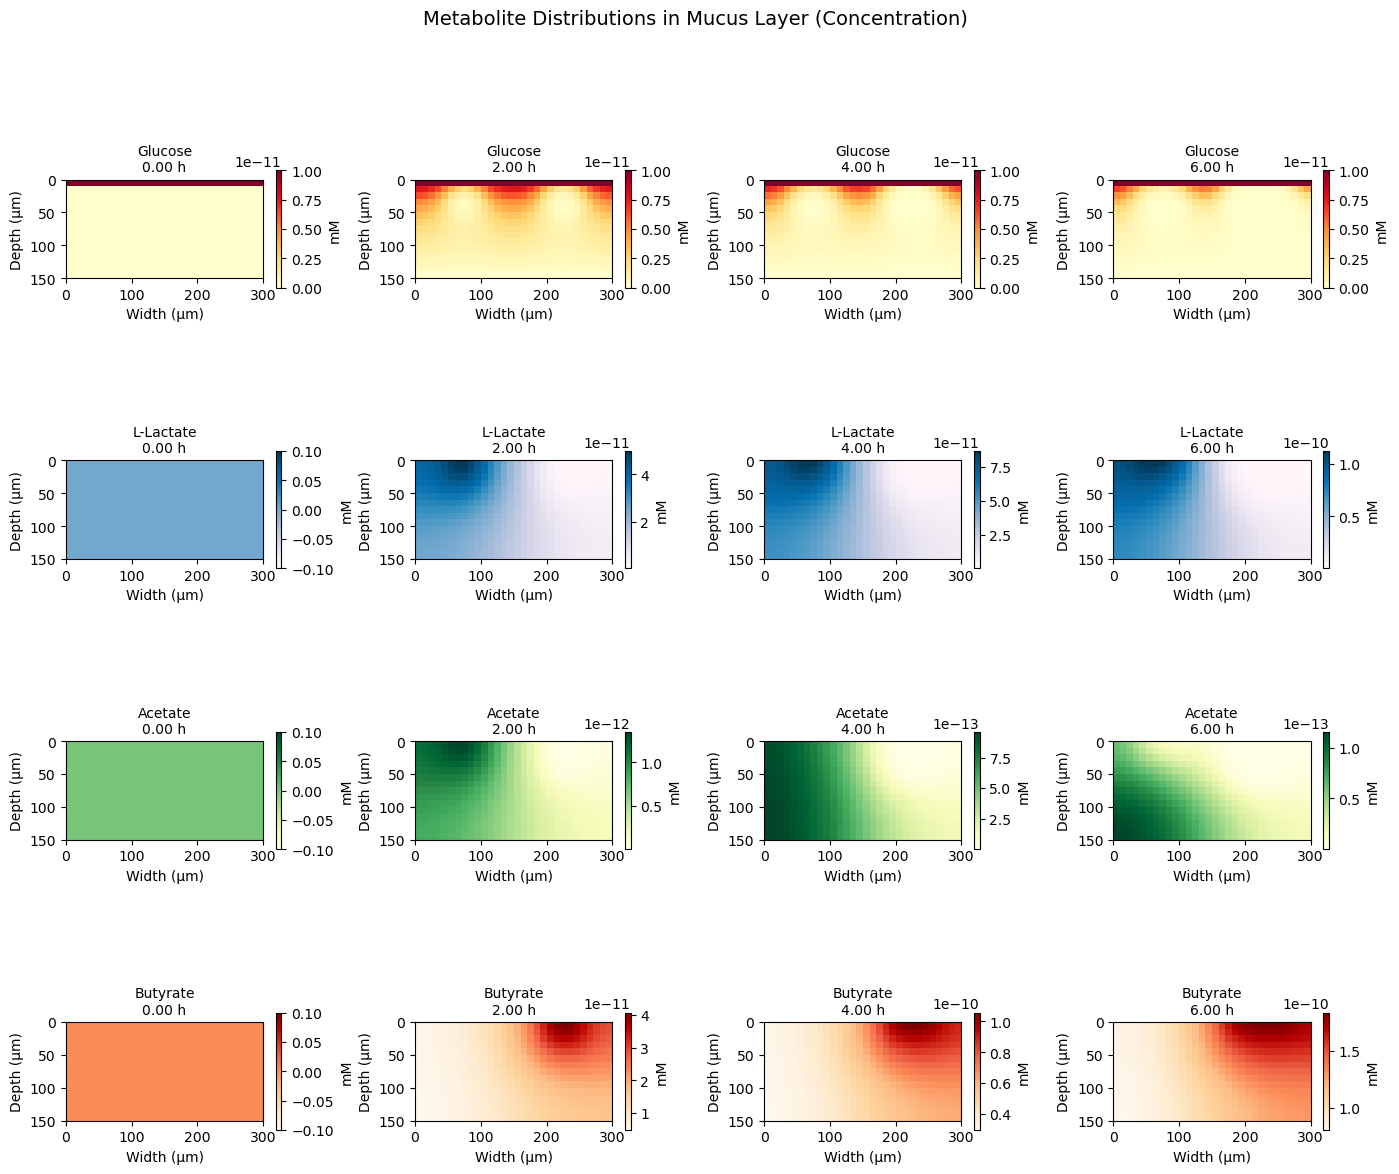

In [18]:
# Metabolite Heatmaps Over Time
cycles = [0, 200, 400, 600]  
metabolites = [
    ('glc_D[e]', 'Glucose', 'YlOrRd'),
    ('lac_L[e]', 'L-Lactate', 'PuBu'),
    ('ac[e]',    'Acetate',  'YlGn'),
    ('but[e]',   'Butyrate', 'OrRd'),
]

n_mets = len(metabolites)

fig, axes = plt.subplots(n_mets, len(cycles), figsize=(3.5*len(cycles), 3*n_mets))
if n_mets == 1:
    axes = axes.reshape(1, -1)

for col, cyc in enumerate(cycles):
    for row, (met_id, met_name, cmap) in enumerate(metabolites):
        ax = axes[row, col]

        # COMETS returns mmol per box; convert to mM
        im = sim.get_metabolite_image(met_id, cyc)
        im_mM = im / BOX_VOL_L  # convert to mM.    im_mM.max()

        pcm = ax.imshow(
            im.T,
            origin='upper',
            cmap=cmap,
            aspect='equal',
            extent=[0, GRID_X*SPACE_WIDTH*1e4, GRID_Y*SPACE_WIDTH*1e4, 0],
        )

        ax.set_title(f'{met_name}\n{cyc*0.01:.2f} h', fontsize=10)
        ax.set_xlabel('Width (µm)')
        ax.set_ylabel('Depth (µm)')
        plt.colorbar(pcm, ax=ax, shrink=0.4, label='mM')

plt.suptitle('Metabolite Distributions in Mucus Layer (Concentration)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

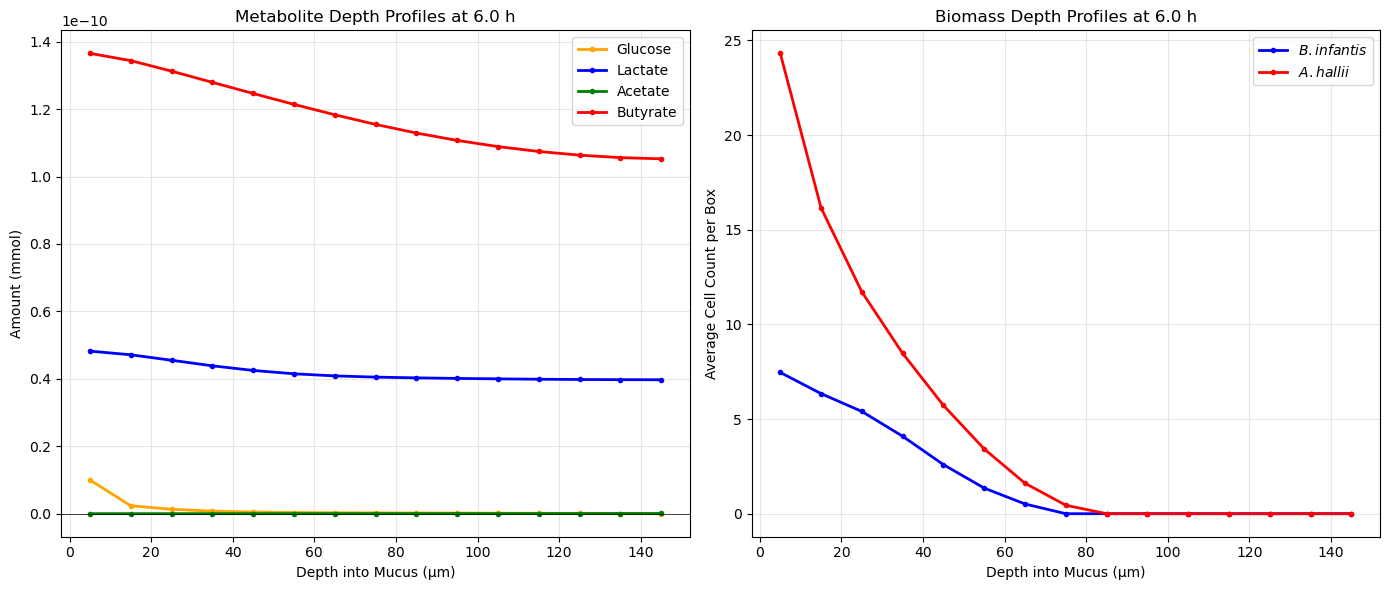

In [19]:
#Amount vs Mucus Depth

cyc = 600
depth_um = np.arange(GRID_Y) * SPACE_WIDTH * 1e4 + SPACE_WIDTH * 1e4 / 2  # center of each row

profile_mets = [
    ('glc_D[e]', 'Glucose', 'orange'),
    ('lac_L[e]', 'Lactate', 'blue'),
    ('ac[e]',    'Acetate', 'green'),
    ('but[e]',   'Butyrate', 'red'),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: metabolite depth profiles
for met_id, met_name, color in profile_mets:

    im = sim.get_metabolite_image(met_id, cyc)
    avg_profile = im.mean(axis=0)  # average across x
    #conc_profile = avg_profile / BOX_VOL_L  # convert to mM
    ax1.plot(depth_um, avg_profile, color=color, linewidth=2, label=met_name, marker='o', markersize=3)


ax1.set_xlabel('Depth into Mucus (µm)')
ax1.set_ylabel('Amount (mmol)')
ax1.set_title(f'Metabolite Depth Profiles at {cyc*0.01:.1f} h')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='k', linewidth=0.5)

# Right: biomass depth profiles
cyc= int(bio['cycle'].max())
for species, color, label in [('b_infantis', 'blue', r'$\it{B. infantis}$'), ('a_hallii', 'red', r'$\it{A. hallii}$')]:
    im = sim.get_biomass_image(species, cyc)
    im = np.roll(im, shift=1, axis=1)
    depth_profile = im.mean(axis=0)  # average across x
    # Convert to cells per box: 1 bacterium ≈ 1e-12 g
    cells_profile = depth_profile / 1e-12
    ax2.plot(depth_um, cells_profile, color=color, linewidth=2, label=label, marker='o', markersize=3)

ax2.set_xlabel('Depth into Mucus (µm)')
ax2.set_ylabel('Average Cell Count per Box')
ax2.set_title(f'Biomass Depth Profiles at {cyc*0.01:.1f} h')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('depth_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

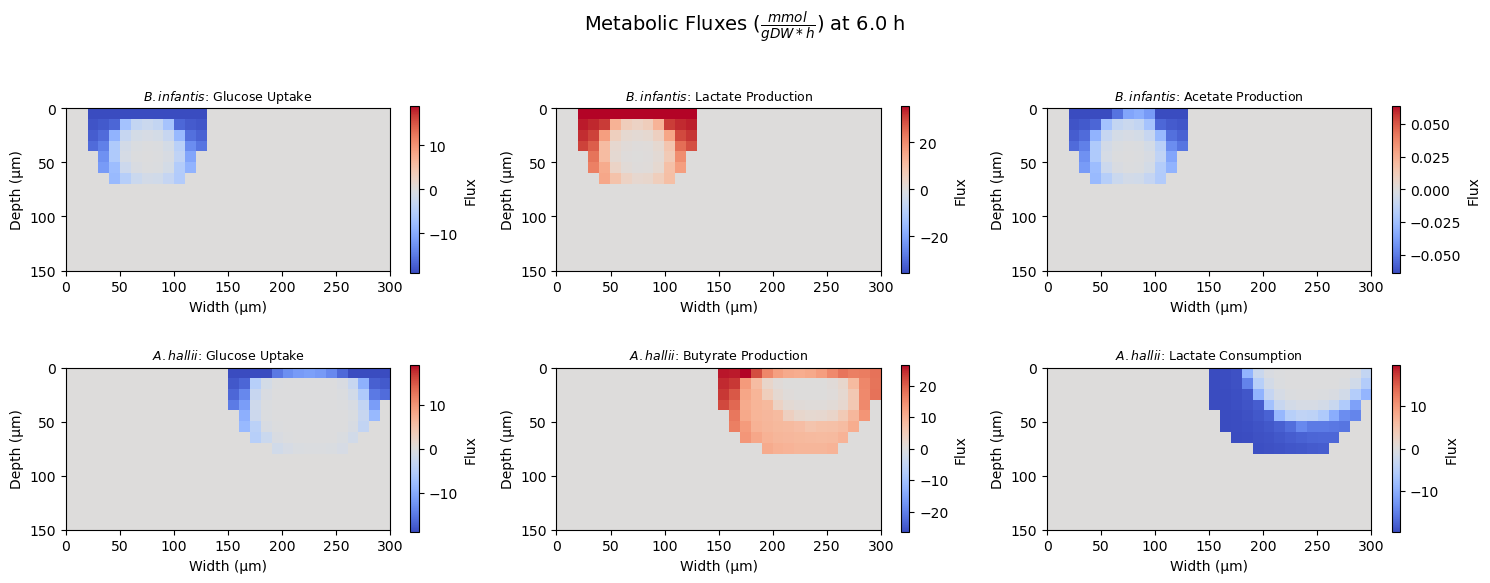

In [20]:
# Key Flux Maps 
max_cycle =  int(bio['cycle'].max())
cyc = max_cycle

flux_pairs = [
    ('b_infantis',      'EX_glc_D(e)',  r'$\it{B. infantis}$: Glucose Uptake'),
    ('b_infantis',      'EX_lac_L(e)',  r'$\it{B. infantis}$: Lactate Production'),
    ('b_infantis',      'EX_ac(e)',     r'$\it{B. infantis}$: Acetate Production'),
    ('a_hallii', 'EX_glc_D(e)',  r'$\it{A. hallii}$: Glucose Uptake'),
    ('a_hallii', 'EX_but(e)',    r'$\it{A. hallii}$: Butyrate Production'),
    ('a_hallii', 'EX_lac_L(e)',  r'$\it{A. hallii}$: Lactate Consumption'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes_flat = axes.flatten()

for idx, (species, rxn, title) in enumerate(flux_pairs):
    ax = axes_flat[idx]

    im = sim.get_flux_image(species, rxn, cyc).astype(float)
    vmax = max(abs(im).max(), 1e-20)
    pcm = ax.imshow(im.T, origin='upper', cmap='coolwarm', aspect='equal',
                    vmin=-vmax, vmax=vmax,
                    extent=[0, GRID_X*SPACE_WIDTH*1e4, GRID_Y*SPACE_WIDTH*1e4, 0])
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Width (µm)')
    ax.set_ylabel('Depth (µm)')
    plt.colorbar(pcm, ax=ax, shrink=0.66, label=r'Flux')


plt.suptitle(r'Metabolic Fluxes ($\frac{mmol}{gDW*h}$) at ' + f'{cyc*0.01:.1f} h', fontsize=14)
plt.tight_layout()
#plt.savefig('flux_maps.png', dpi=150, bbox_inches='tight')
plt.show()

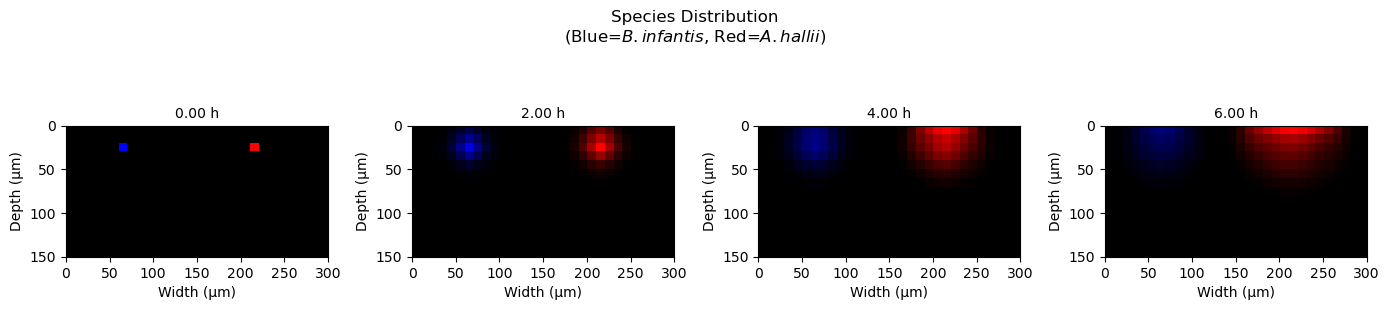

In [21]:
# Species Overlay 

cycles = [0, 200, 400, 600]  

fig, axes = plt.subplots(1, len(cycles), figsize=(3.5*len(cycles), 3))
if len(cycles) == 1:
    axes = [axes]

for i, cyc in enumerate(cycles):
    ax = axes[i]

    im_BI = sim.get_biomass_image('b_infantis', cyc)
    im_AH = sim.get_biomass_image('a_hallii', cyc)
    im_BI = np.roll(im_BI, shift=1, axis=1)  # bug fix with np.roll
    im_AH = np.roll(im_AH, shift=1, axis=1)

    # Normalize both species to [0, 1] using a common scale
    bmax = max(im_BI.max(), 1e-20)
    emax = max(im_AH.max(), 1e-20)
    scale = max(bmax, emax)

    rgb = np.zeros((GRID_Y, GRID_X, 3))
    rgb[:, :, 2] = (im_BI / scale).T  # Bifido = blue
    rgb[:, :, 0] = (im_AH / scale).T  # Eubacterium = red
    rgb = np.clip(rgb, 0, 1)

    ax.imshow(
        rgb,
        origin='upper',
        aspect='equal',
        extent=[0, GRID_X*SPACE_WIDTH*1e4, GRID_Y*SPACE_WIDTH*1e4, 0],
    )
    ax.set_title(f'{cyc*0.01:.2f} h', fontsize=10)
    ax.set_xlabel('Width (µm)')
    ax.set_ylabel('Depth (µm)')



plt.suptitle('Species Distribution\n'+r'(Blue=$\it{B. infantis}$, Red=$\it{A. hallii}$)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

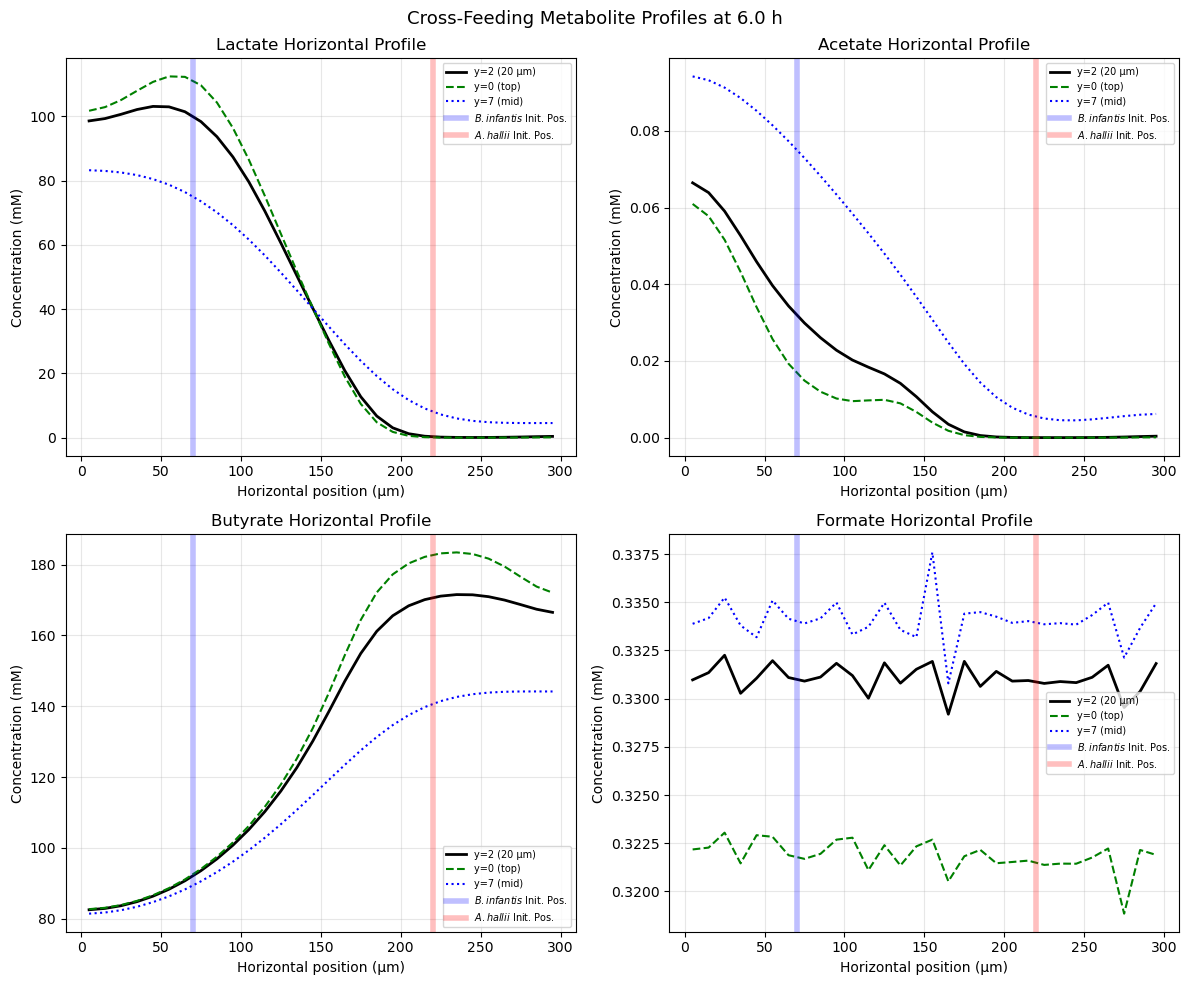

In [22]:
# Analyze metabolite exchange between species

cyc = max_cycle

crossfeed_mets = [
    ('lac_L[e]', 'Lactate'),
    ('ac[e]', 'Acetate'),
    ('but[e]', 'Butyrate'),
    ('for[e]', 'Formate'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes_flat = axes.flatten()
x_um = np.arange(GRID_X) * SPACE_WIDTH * 1e4 + SPACE_WIDTH * 1e4 / 2

for idx, (met_id, met_name) in enumerate(crossfeed_mets):
    ax = axes_flat[idx]

    im = sim.get_metabolite_image(met_id, cyc)
    im_mM = im / BOX_VOL_L
    
    # Profile at y=2 (inoculation row)
    profile_y2 = im_mM[:, y_init]
    ax.plot(x_um, profile_y2, 'k-', linewidth=2, label=f'y={y_init} ({y_init*10} µm)')
    
    # Profile at y=0 (top)
    profile_y0 = im_mM[:, 0]
    ax.plot(x_um, profile_y0, 'g--', linewidth=1.5, label='y=0 (top)')
    
    # Profile at y=7 (mid-depth)
    profile_ymid = im_mM[:, GRID_Y//2]
    ax.plot(x_um, profile_ymid, 'b:', linewidth=1.5, label=f'y={GRID_Y//2} (mid)')
    
    ax.axvline(x=x_init_BI*SPACE_WIDTH*1e4, color='blue', lw=4, linestyle='solid', alpha=0.25, label=r'$\it{B. infantis}$ Init. Pos.')
    ax.axvline(x=x_init_AH*SPACE_WIDTH*1e4, color='red', lw=4, linestyle='solid', alpha=0.25, label=r'$\it{A. hallii}$ Init. Pos.')

    ax.set_xlabel('Horizontal position (µm)')
    ax.set_ylabel('Concentration (mM)')
    ax.set_title(f'{met_name} Horizontal Profile')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
   
plt.suptitle(f'Cross-Feeding Metabolite Profiles at {cyc*0.01:.1f} h', fontsize=13)
plt.tight_layout()
#plt.savefig('crossfeeding_analysis.png', dpi=150, bbox_inches='tight')
plt.show()